In [1]:
import os
import astropy.io.fits as fits
import pandas as pd
from datetime import datetime, timedelta
import math  # Import the math module for rounding up

folder_path = 'C:\\Users\\Observatory\\Exo\\Data\\Standard-stars\\Wolf1346_2024_10_02'
frame_names = []
filters = []
modes = []
exposure_times = []
starts = []
utcs = []


def utc_time_from_iso(iso_string):
    """Converts an ISO format datetime string to UTC time."""
    try:
        dt_obj = datetime.fromisoformat(iso_string)
        utc_time = dt_obj - timedelta(hours=3, minutes=30)  # Subtract for UTC
        return utc_time.strftime('%H:%M:%S.000')  # Only time
    except ValueError:
        return None


for filename in os.listdir(folder_path):
    if filename.endswith('.fit'):
        try:
            filepath = os.path.join(folder_path, filename)
            with fits.open(filepath) as hdul:
                header = hdul[0].header

                frame_names.append(filename)

                # Extract filter
                parts = filename.split('-')
                filters.append(filename.split('_')[0][-1] if '_' in filename else None)

                # Extract mode (between '1x1_' and the next '_')
                mode_start = filename.find('1x1_')
                if mode_start != -1:
                    mode_start += 4  # Move past '1x1_'
                    mode_end = filename.find('_', mode_start)
                    if mode_end != -1:
                        modes.append(filename[mode_start:mode_end])
                    else:
                        modes.append(None)  # No underscore after 1x1_
                else:
                    modes.append(None)  # 1x1_ not found

                # Convert exposure time to seconds and round up to an integer
                exptime_us = header.get('EXPTIME')
                if exptime_us is not None:
                    exptime_seconds = math.ceil(exptime_us / 100000)  # Convert to seconds and round up
                else:
                    exptime_seconds = None  # If the value cannot be retrieved assign it to None
                exposure_times.append(exptime_seconds)

                start = header.get('DATE-OBS')
                if start:
                    start = start.replace(" NOGPS", "")  # Remove " NOGPS" from `start`
                    try:
                        start_time = datetime.fromisoformat(start).strftime('%H:%M:%S.000')  # Convert to time format
                        starts.append(start_time)
                    except ValueError:
                        starts.append(None)  # Handle invalid date formats
                else:
                    starts.append(None)

                utcs.append(utc_time_from_iso(start) if start else None)

        except Exception as e:
            print(f"Error processing filename {filename}: {e}")
            frame_names.append(filename)
            filters.append(None)
            modes.append(None)
            exposure_times.append(None)
            starts.append(None)
            utcs.append(None)

df = pd.DataFrame({
    'Frame Name': frame_names,
    'Filter': filters,
    'Mode': modes,
    'ExposureTime': exposure_times,
    'Start': starts,
    'UTC': utcs
})

# Print the DataFrame to the screen
print(df)

# Save the DataFrame to a CSV file, overwriting if it exists
csv_file_path = os.path.join(folder_path, "frames-report.csv")  # Choose a filename and location
df.to_csv(csv_file_path, index=False, mode='w', header=True)  # index=False, write in w mode to overwrite

print(f"DataFrame saved to: {csv_file_path}")

                                            Frame Name Filter   Mode  \
0     wolf-g_2024_10_02_exp00.00.05.000_1x1_High_1.fit      g   High   
1    wolf-g_2024_10_02_exp00.00.05.000_1x1_High_10.fit      g   High   
2    wolf-g_2024_10_02_exp00.00.05.000_1x1_High_11.fit      g   High   
3    wolf-g_2024_10_02_exp00.00.05.000_1x1_High_12.fit      g   High   
4    wolf-g_2024_10_02_exp00.00.05.000_1x1_High_13.fit      g   High   
..                                                 ...    ...    ...   
181  wolf-r_2024_10_02_exp00.00.05.000_1x1_Merge_5.fit      r  Merge   
182  wolf-r_2024_10_02_exp00.00.05.000_1x1_Merge_6.fit      r  Merge   
183  wolf-r_2024_10_02_exp00.00.05.000_1x1_Merge_7.fit      r  Merge   
184  wolf-r_2024_10_02_exp00.00.05.000_1x1_Merge_8.fit      r  Merge   
185  wolf-r_2024_10_02_exp00.00.05.000_1x1_Merge_9.fit      r  Merge   

     ExposureTime         Start           UTC  
0               5  19:16:41.000  15:46:41.000  
1               5  20:37:42.000  17:07:

Plot saved to: C:\Users\Observatory\Exo\Data\Standard-stars\Wolf1346_2024_10_02\wolf_2024-10-02_exposure_times_plot.png


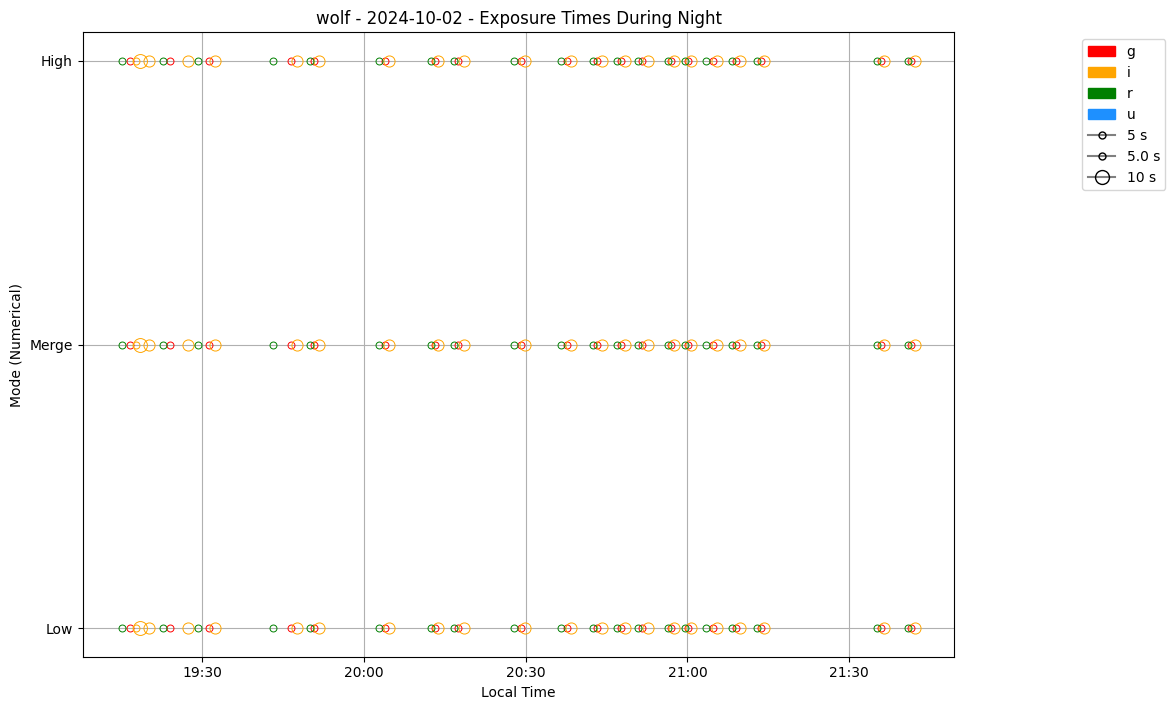

In [2]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import pandas as pd
from datetime import datetime, timedelta
import os
import astropy.io.fits as fits  # Ensure you have this import


folder_path = 'C:\\Users\\Observatory\\Exo\\Data\\Standard-stars\\Wolf1346_2024_10_02'  # Important
# --- Manually Define Observation Date ---
dateobs = "2024-10-02"  # Change this date as needed

frame_names = []
filters = []
modes = []
exposure_times = []
starts = []
utcs = []


def utc_time_from_iso(iso_string):
    """Converts an ISO format datetime string to UTC time."""
    try:
        dt_obj = datetime.fromisoformat(iso_string)
        utc_time = dt_obj - timedelta(hours=3, minutes=30)  # Subtract for UTC
        return utc_time.strftime('%H:%M:%S.000')  # Only time
    except ValueError:
        return None


for filename in os.listdir(folder_path):
    if filename.endswith('.fit'):
        try:
            filepath = os.path.join(folder_path, filename)
            with fits.open(filepath) as hdul:
                header = hdul[0].header

                frame_names.append(filename)

                # Extract filter (assuming it's still after the first '-')
                parts = filename.split('-')
                filters.append(filename.split('_')[0][-1] if '_' in filename else None)


                # Extract mode (between '1x1_' and the next '_')
                mode_start = filename.find('1x1_')
                if mode_start != -1:
                    mode_start += 4  # Move past '1x1_'
                    mode_end = filename.find('_', mode_start)
                    if mode_end != -1:
                        modes.append(filename[mode_start:mode_end])
                    else:
                        modes.append(None)  # No underscore after 1x1_
                else:
                    modes.append(None)  # 1x1_ not found

                # Convert exposure time to seconds and round up to an integer
                exptime_us = header.get('EXPTIME')
                if exptime_us is not None:
                    exptime_seconds = math.ceil(exptime_us / 100000)  # Convert to seconds and round up
                else:
                    exptime_seconds = None  # If the value cannot be retrieved assign it to None
                exposure_times.append(exptime_seconds)

                start = header.get('DATE-OBS')
                if start:
                    start = start.replace(" NOGPS", "")  # Remove " NOGPS" from `start`
                    starts.append(start)  # Append the full date and time string

                else:
                    starts.append(None)

                utcs.append(utc_time_from_iso(start) if start else None)

        except Exception as e:
            print(f"Error processing filename {filename}: {e}")
            frame_names.append(filename)
            filters.append(None)
            modes.append(None)
            exposure_times.append(None)
            starts.append(None)
            utcs.append(None)


df = pd.DataFrame({
    'Frame Name': frame_names,
    'Filter': filters,
    'Mode': modes,
    'ExposureTime': exposure_times,
    'Start': starts,
    'UTC': utcs
})

# Extract object name from the first filename (assuming all have the same object)
if frame_names:  # Check if the list is not empty
    object_name = frame_names[0].split('-')[0]
else:
    object_name = "UnknownObject"  # Default if no frames are found
    print("Warning: No FITS files found. Setting object name to 'UnknownObject'")


# Mapping filters to colors
filter_colors = {
    'g': 'red',
    'i': 'orange',
    'r': 'green',
    'u': 'dodgerblue'  
}

# Mapping modes to numerical values
mode_mapping = {
    'Low': 0,
    'High': 1,
    'Merge': 0.5
}

# Prepare data for plotting
x = df['Start']  # Changed to Start
y = [mode_mapping.get(m, -1) for m in df['Mode']]  # Map modes to numbers, default to -1
colors = [filter_colors.get(f, 'gray') for f in df['Filter']]  # Default to gray if filter is unknown
radii = df['ExposureTime']  # Use exposure time as radii

# Convert Tehran Time strings to datetime objects
try:
    x = pd.to_datetime(x)
except ValueError as e:
    print(f"Error converting Tehran Time to datetime: {e}")
    print("Please verify the format of your Tehran Time column.")
    exit()

# Create the plot
plt.figure(figsize=(12, 8))  # Adjust figure size as needed

# Plot each point
for i in range(len(df)):
    if y[i] != -1:  # Skip plotting if mode is unknown
        plt.plot(x[i], y[i], marker='o', markersize=radii[i], markeredgecolor=colors[i],
                 markerfacecolor='none', markeredgewidth=0.7)  # Increased line width

# Customize the plot
plt.xlabel("Local Time")  # Changed the label
plt.ylabel("Mode (Numerical)")  # Reflected the value
plt.title(f"{object_name} - {dateobs} - Exposure Times During Night")  # updated the title

# Set y-axis ticks and labels to reflect mode values
plt.yticks(list(mode_mapping.values()), list(mode_mapping.keys()))

# Reduce the number of x-axis ticks
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))  # Format as HH:MM

plt.grid(True)

# --- Add Legends ---

# Create filter legend
filter_patches = [mpatches.Patch(color=color, label=filter_name)
                  for filter_name, color in filter_colors.items()]

# Create a size legend
size_values = [min(df['ExposureTime']), df['ExposureTime'].median(), max(df['ExposureTime'])]  # Example sizes
size_labels = [f"{size} s" for size in size_values]
size_patches = [plt.Line2D([0], [0], marker='o', color='gray', markerfacecolor='none',
                           markeredgecolor='black', markersize=size, label=label)
                for size, label in zip(size_values, size_labels)]

# Combine the legends
all_legends = filter_patches + size_patches

# Add the legend to the plot
plt.legend(handles=all_legends, loc='upper right', bbox_to_anchor=(1.25, 1))  # Adjust location as needed

# Adjust layout to make room for the legend
plt.tight_layout(rect=[0, 0, 1, 0.9])  # move all other graph elements to fit the legend.

# Save the plot
plot_file_path = os.path.join(folder_path, f"{object_name}_{dateobs}_exposure_times_plot.png")
plt.savefig(plot_file_path)
print(f"Plot saved to: {plot_file_path}")

# Display the plot
plt.show()